# B4T1 - Diseño de Redes Confiables
## Parte 1: Arquitectura Customizada + Modelo Base

## 1. Imports

In [101]:
import os, sys, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import keras

# La lógica reutilizable vive en src/base.py (única fuente de verdad,
# compartida con 02_fair_loss.ipynb).
ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.base import (
    load_home_credit_data, RatioEndeudamientoLayer, build_model,
    compute_class_weight_balanced,
)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

DATA_PATH = os.path.join(ROOT, "data", "application_train.csv")
RESULTS = os.path.join(ROOT, "results")
os.makedirs(RESULTS, exist_ok=True)

## 2. Carga y preprocesado de datos

El preprocesado está implementado en `src.base.load_home_credit_data` (ver el
módulo para el detalle). Resumen: selecciona las columnas de interés, elimina
géneros desconocidos, codifica el **género** (variable sensible) como `M=0, F=1`,
convierte `DAYS_BIRTH` a edad, imputa `EXT_SOURCE_*`/`AMT_ANNUITY` con la mediana
(añadiendo flags `_NULL`), hace split estratificado 80/20 y escala con
`StandardScaler`. Devuelve `(X, y, s)` para train y test.

In [102]:
(X_train, y_train, s_train), (X_test, y_test, s_test) = load_home_credit_data(DATA_PATH)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Tasa de impago: {y_train.mean():.3f}")

X_train: (246005, 11)
X_test:  (61502, 11)
Tasa de impago: 0.081


## 3. Análisis exploratorio (EDA)

In [103]:
df_raw = pd.read_csv(DATA_PATH)

# Nulos en las columnas que usamos
cols_interes = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AMT_ANNUITY']
nulos = df_raw[cols_interes].isnull().sum()
porcentaje = (nulos / len(df_raw) * 100).round(2)

pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': porcentaje})

,Nulos,Porcentaje (%)
EXT_SOURCE_1,173378,56.38
EXT_SOURCE_2,660,0.21
EXT_SOURCE_3,60965,19.83
AMT_ANNUITY,12,0.00


Tasa de impago: 8.07%


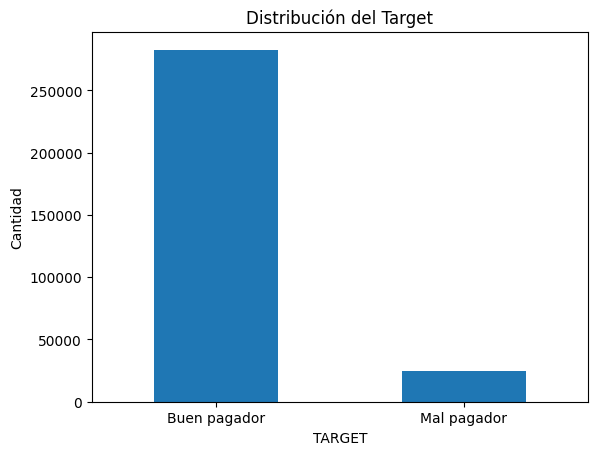

In [104]:
# Distribución del target
target_counts = df_raw['TARGET'].value_counts()
porcentaje_impago = df_raw['TARGET'].mean() * 100

print(f"Tasa de impago: {porcentaje_impago:.2f}%")
target_counts.plot(kind='bar')
plt.title('Distribución del Target')
plt.xticks([0, 1], ['Buen pagador', 'Mal pagador'], rotation=0)
plt.ylabel('Cantidad')
plt.show()

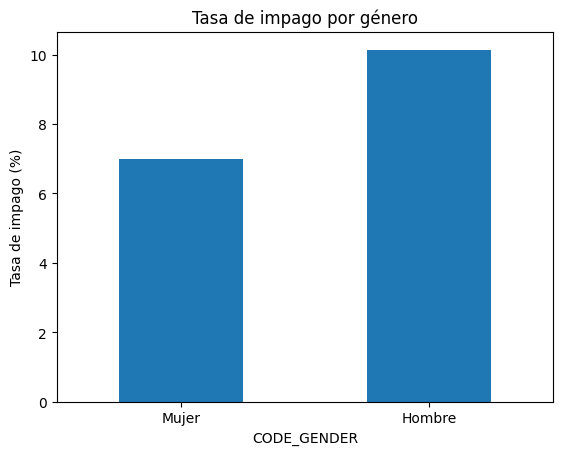

In [105]:
# Tasa de impago por género
impago_genero = df_raw[df_raw['CODE_GENDER'].isin(['M', 'F'])].groupby('CODE_GENDER')['TARGET'].mean() * 100

impago_genero.plot(kind='bar')
plt.title('Tasa de impago por género')
plt.xticks([0, 1], ['Mujer', 'Hombre'], rotation=0)
plt.ylabel('Tasa de impago (%)')
plt.show()

### Conclusiones del EDA
- El dataset está muy desbalanceado: solo el 8% son malos pagadores.
Se deberá compensar durante el entrenamiento dando más peso a la clase positiva.
- EXT_SOURCE_1 tiene un 56% de nulos y EXT_SOURCE_3 un 20%.
Se imputan con la mediana y se añade un flag por columna para que la red sepa dónde faltaba información.
- Existe una diferencia real en la tasa de impago por género (hombres ~10% vs mujeres ~7%),
lo que justifica la necesidad de una FAIR loss para evitar discriminación.

## 4. Arquitectura customizada: Ratio de Endeudamiento

La capa `RatioEndeudamientoLayer` (definida en `src/base.py`) calcula internamente
una señal de **carga de endeudamiento** combinando variables financieras de entrada
(`AMT_CREDIT`, `AMT_ANNUITY`, `AMT_INCOME_TOTAL`) y le aplica una **saturación
`tanh`** (restricción matemática que acota la señal a `(-1, 1)`) antes de
concatenarla al vector de features. Es una transformación determinista (sin
parámetros entrenables): una restricción "física" sobre el problema.

In [106]:
# Demostración: la capa añade 1 feature (la señal de endeudamiento saturada)
capa = RatioEndeudamientoLayer()
demo = capa(keras.ops.convert_to_tensor(X_train[:3], dtype="float32"))
print("Entrada:", X_train[:3].shape, "-> Salida de la capa:", tuple(demo.shape))

Entrada: (3, 11) -> Salida de la capa: (3, 12)


## 5. Modelo Base

Arquitectura (en `src.base.build_model`): `Input → RatioEndeudamientoLayer →
Dense(64, relu) → Dropout → Dense(32, relu) → Dropout → Dense(1, sigmoid)`. Se
entrena con **BCE** y `class_weight` balanceado. Esta es exactamente la misma
arquitectura sobre la que `02_fair_loss.ipynb` aplica la FAIR loss.

In [107]:
model = build_model(X_train.shape[1])
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[keras.metrics.AUC(name="auc")],
)
model.summary()

Model: "credit_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ratio_endeudamiento             │ (None, 12)             │             0 │
│ (RatioEndeudamientoLayer)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pd (Dense)                      │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [108]:
cw = compute_class_weight_balanced(y_train)
es = keras.callbacks.EarlyStopping(
    monitor="val_auc", 
    patience=10, 
    restore_best_weights=True,
    mode="max"
)

history = model.fit(
    X_train, np.asarray(y_train).astype("float32"),
    validation_split=0.15,
    epochs=40, batch_size=512, class_weight=cw,
    verbose=2, callbacks=[es],
)

Epoch 1/40
409/409 - 5s - 12ms/step - auc: 0.6954 - loss: 0.6409 - val_auc: 0.7288 - val_loss: 0.6138
Epoch 2/40
409/409 - 4s - 9ms/step - auc: 0.7033 - loss: 0.6312 - val_auc: 0.7302 - val_loss: 0.6091
Epoch 3/40
409/409 - 4s - 10ms/step - auc: 0.7055 - loss: 0.6281 - val_auc: 0.7288 - val_loss: 0.6077
Epoch 4/40
409/409 - 4s - 9ms/step - auc: 0.7099 - loss: 0.6249 - val_auc: 0.7292 - val_loss: 0.6141
Epoch 5/40
409/409 - 4s - 9ms/step - auc: 0.7110 - loss: 0.6246 - val_auc: 0.7290 - val_loss: 0.6176
Epoch 6/40
409/409 - 4s - 10ms/step - auc: 0.7101 - loss: 0.6235 - val_auc: 0.7293 - val_loss: 0.6125
Epoch 7/40
409/409 - 4s - 9ms/step - auc: 0.7098 - loss: 0.6237 - val_auc: 0.7276 - val_loss: 0.6168
Epoch 8/40
409/409 - 4s - 9ms/step - auc: 0.7087 - loss: 0.6253 - val_auc: 0.7269 - val_loss: 0.6197
Epoch 9/40
409/409 - 4s - 9ms/step - auc: 0.7097 - loss: 0.6259 - val_auc: 0.7260 - val_loss: 0.6192
Epoch 10/40
409/409 - 4s - 9ms/step - auc: 0.7105 - loss: 0.6235 - val_auc: 0.7264 - val

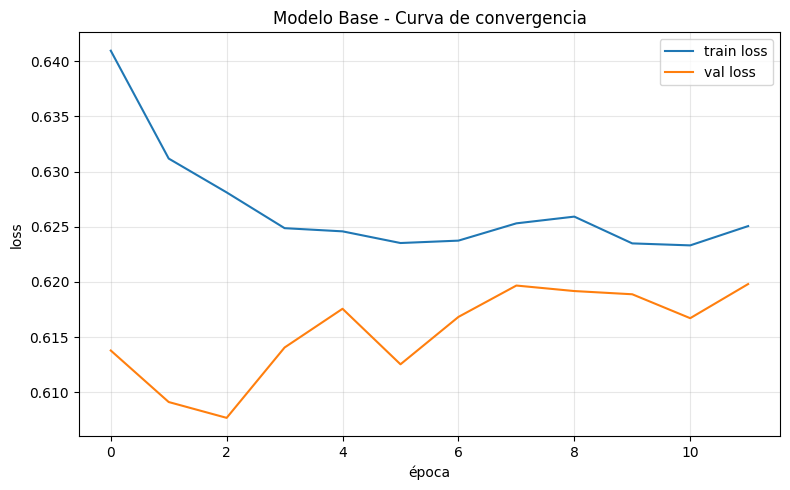

In [109]:
# Curva de loss (convergencia) -> results/loss_curve_base.png
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.title("Modelo Base - Curva de convergencia")
plt.xlabel("época"); plt.ylabel("loss"); plt.grid(alpha=0.3); plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "loss_curve_base.png"), dpi=130)
plt.show()

In [110]:
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score

p_test = model.predict(X_test, verbose=0, batch_size=4096).ravel()
print(f"Accuracy: {accuracy_score(y_test, (p_test >= 0.5).astype(int)):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, p_test):.4f}")
print(f"PR-AUC:   {average_precision_score(y_test, p_test):.4f}")

Accuracy: 0.6739
ROC-AUC:  0.7288
PR-AUC:   0.2076


In [111]:
from sklearn.metrics import classification_report
print(classification_report(y_test, (p_test >= 0.5).astype(int), 
      target_names=['Buen pagador', 'Mal pagador']))

              precision    recall  f1-score   support

Buen pagador       0.96      0.67      0.79     56537
 Mal pagador       0.15      0.67      0.25      4965

    accuracy                           0.67     61502
   macro avg       0.56      0.67      0.52     61502
weighted avg       0.89      0.67      0.75     61502



### Conclusiones del Modelo Base

El modelo base con la capa customizada `RatioEndeudamientoLayer` converge 
correctamente. La train loss baja progresivamente y se estabiliza, indicando 
que el modelo ha aprendido.

La val loss aparece por debajo de la train loss porque el `class_weight` 
balanceado (11x) solo se aplica durante el entrenamiento — aumenta 
artificialmente la loss de train al penalizar más los errores en malos 
pagadores, pero no afecta al cálculo de la val loss. El ligero ruido en 
val loss es también consecuencia de este desbalanceo.

**Resultados en test:**
- ROC-AUC: ~0.73 — el modelo distingue razonablemente entre buenos y malos pagadores
- Recall mal pagador: 0.67 — detecta el 67% de los impagos, prioritario en riesgo crediticio
- Este modelo sin restricciones FAIR es el punto de referencia para comparar 
con el modelo justo de la Parte 2